# PS0b — Floquet Multiplier Validation
## Option C: HH Delay-Directed Orbit Selection
### HHSMC Project — March 2026

Computes Floquet multipliers for representative orbits from the PS1 libraryto validate the empirical stability claims made throughout the paper.

**Method:** Tangent Linear Model (TLM) propagation with QR reorthogonalisation. For each orbit, 4 orthogonal perturbation vectors are propagated through thelinearised DDE for multiple periods. After each period, QR decompositionextracts the per-period growth factors, which converge to the Floquetmultipliers of the periodic orbit.

**Reference:** Dieci & Van Vleck, *Computation of a few Lyapunov exponentsfor continuous and discrete dynamical systems*, Appl. Numer. Math. 17 (1995) 275–291.

## CELL 1 — Setup and Imports

In [10]:
import numpy as np
from numba import njit
import matplotlib.pyplot as plt
import json, os, time
from datetime import datetime

# --- Google Drive Mount ---
try:
    from google.colab import drive
    drive.mount('/content/drive')
    PS1_DIR = '/content/drive/My Drive/HHSMC/full_study/PS1_write_protocol'
    OUTPUT_DIR = '/content/drive/My Drive/HHSMC/full_study/PS0b_floquet'
except ImportError:
    PS1_DIR = './PS1_results'
    OUTPUT_DIR = './PS0b_results'

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"PS1 input:  {PS1_DIR}")
print(f"Output dir: {OUTPUT_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PS1 input:  /content/drive/My Drive/HHSMC/full_study/PS1_write_protocol
Output dir: /content/drive/My Drive/HHSMC/full_study/PS0b_floquet


## CELL 2 — HH Model (V-shifted convention, rest = 0)

In [11]:
# --- Fixed biophysical parameters ---
C_M  = 1.0      # μF/cm²
G_NA = 120.0     # mS/cm²
G_K  = 36.0      # mS/cm²
G_L  = 0.3       # mS/cm²
E_NA = 115.0     # mV (V-shifted)
E_K  = -12.0     # mV (V-shifted)
E_L  = 10.6      # mV (V-shifted)
DT   = 0.01      # ms integration step

@njit
def alpha_m(V):
    x = 25.0 - V
    if abs(x) < 1e-7:
        return 1.0
    return 0.1 * x / (np.exp(x / 10.0) - 1.0)

@njit
def beta_m(V):
    return 4.0 * np.exp(-V / 18.0)

@njit
def alpha_h(V):
    return 0.07 * np.exp(-V / 20.0)

@njit
def beta_h(V):
    return 1.0 / (np.exp((30.0 - V) / 10.0) + 1.0)

@njit
def alpha_n(V):
    x = 10.0 - V
    if abs(x) < 1e-7:
        return 0.1
    return 0.01 * x / (np.exp(x / 10.0) - 1.0)

@njit
def beta_n(V):
    return 0.125 * np.exp(-V / 80.0)

@njit
def hh_rhs(V, m, h, n, I_total):
    I_Na = G_NA * m*m*m * h * (V - E_NA)
    I_K  = G_K * n*n*n*n * (V - E_K)
    I_L  = G_L * (V - E_L)
    dV = (I_total - I_Na - I_K - I_L) / C_M
    dm = alpha_m(V) * (1.0 - m) - beta_m(V) * m
    dh = alpha_h(V) * (1.0 - h) - beta_h(V) * h
    dn = alpha_n(V) * (1.0 - n) - beta_n(V) * n
    return dV, dm, dh, dn

@njit
def hh_steady_state(V):
    am = alpha_m(V); bm = beta_m(V)
    ah = alpha_h(V); bh = beta_h(V)
    an = alpha_n(V); bn = beta_n(V)
    return am/(am+bm), ah/(ah+bh), an/(an+bn)

## CELL 3 — Reference Orbit Simulation
Simulates the HH-DFC orbit until periodic, then stores the full statetrajectory (V, m, h, n) at every dt step for one precisely measured period.This stored trajectory is used by the Tangent Linear Model in Cell 5.

In [12]:
@njit
def simulate_reference_orbit(I_bias, K, tau_ms, T_settle_ms, T_record_ms, dt=0.01):
    """
    Simulate HH-DFC orbit and store full state trajectory for the recording window.

    Parameters
    ----------
    T_settle_ms : float — settling time before recording (discard transient)
    T_record_ms : float — recording window (should be >= several orbit periods)

    Returns
    -------
    V_rec, m_rec, h_rec, n_rec : arrays of state at each dt during recording
    spike_times : spike times during recording window (relative to record start)
    V_buf_snapshot : delay buffer state at start of recording (for TLM init)
    """
    buf_size = max(int(tau_ms / dt), 1)

    # Initial conditions
    V = 0.0
    m, h, n = hh_steady_state(V)
    V_buf = np.zeros(buf_size)

    # Warm-start delay buffer (RC3)
    for ws in range(buf_size):
        I_total = I_bias
        dV1, dm1, dh1, dn1 = hh_rhs(V, m, h, n, I_total)
        V2 = V + 0.5*dt*dV1; m2 = m + 0.5*dt*dm1
        h2 = h + 0.5*dt*dh1; n2 = n + 0.5*dt*dn1
        dV2, dm2, dh2, dn2 = hh_rhs(V2, m2, h2, n2, I_total)
        V3 = V + 0.5*dt*dV2; m3 = m + 0.5*dt*dm2
        h3 = h + 0.5*dt*dh2; n3 = n + 0.5*dt*dn2
        dV3, dm3, dh3, dn3 = hh_rhs(V3, m3, h3, n3, I_total)
        V4 = V + dt*dV3; m4 = m + dt*dm3
        h4 = h + dt*dh3; n4 = n + dt*dn3
        dV4, dm4, dh4, dn4 = hh_rhs(V4, m4, h4, n4, I_total)
        V += (dt/6.0)*(dV1+2*dV2+2*dV3+dV4)
        m = min(max(m + (dt/6.0)*(dm1+2*dm2+2*dm3+dm4), 0.0), 1.0)
        h = min(max(h + (dt/6.0)*(dh1+2*dh2+2*dh3+dh4), 0.0), 1.0)
        n = min(max(n + (dt/6.0)*(dn1+2*dn2+2*dn3+dn4), 0.0), 1.0)
        V_buf[ws % buf_size] = V

    buf_idx = 0

    # Settle phase
    n_settle = int(T_settle_ms / dt)
    V_prev = V
    for step in range(n_settle):
        V_delayed = V_buf[buf_idx]
        I_ctrl = K * (V_delayed - V)
        I_total = I_bias + I_ctrl

        dV1, dm1, dh1, dn1 = hh_rhs(V, m, h, n, I_total)
        Vk2 = V + 0.5*dt*dV1; I2 = I_bias + K*(V_delayed - Vk2)
        mk2 = m + 0.5*dt*dm1; hk2 = h + 0.5*dt*dh1; nk2 = n + 0.5*dt*dn1
        dV2, dm2, dh2, dn2 = hh_rhs(Vk2, mk2, hk2, nk2, I2)
        Vk3 = V + 0.5*dt*dV2; I3 = I_bias + K*(V_delayed - Vk3)
        mk3 = m + 0.5*dt*dm2; hk3 = h + 0.5*dt*dh2; nk3 = n + 0.5*dt*dn2
        dV3, dm3, dh3, dn3 = hh_rhs(Vk3, mk3, hk3, nk3, I3)
        Vk4 = V + dt*dV3; I4 = I_bias + K*(V_delayed - Vk4)
        mk4 = m + dt*dm3; hk4 = h + dt*dh3; nk4 = n + dt*dn3
        dV4, dm4, dh4, dn4 = hh_rhs(Vk4, mk4, hk4, nk4, I4)

        V_new = V + (dt/6.0)*(dV1+2*dV2+2*dV3+dV4)
        m = min(max(m + (dt/6.0)*(dm1+2*dm2+2*dm3+dm4), 0.0), 1.0)
        h = min(max(h + (dt/6.0)*(dh1+2*dh2+2*dh3+dh4), 0.0), 1.0)
        n = min(max(n + (dt/6.0)*(dn1+2*dn2+2*dn3+dn4), 0.0), 1.0)
        V_buf[buf_idx] = V_new
        buf_idx = (buf_idx + 1) % buf_size
        V_prev = V; V = V_new

    # Snapshot delay buffer at recording start
    V_buf_snapshot = V_buf.copy()
    buf_idx_snapshot = buf_idx

    # Recording phase — store full state at every dt
    n_record = int(T_record_ms / dt)
    V_rec = np.empty(n_record)
    m_rec = np.empty(n_record)
    h_rec = np.empty(n_record)
    n_rec = np.empty(n_record)

    max_spk = int(T_record_ms / 2) + 100
    spike_times = np.empty(max_spk)
    n_spk = 0
    V_prev = V

    for step in range(n_record):
        V_delayed = V_buf[buf_idx]
        I_ctrl = K * (V_delayed - V)
        I_total = I_bias + I_ctrl

        dV1, dm1, dh1, dn1 = hh_rhs(V, m, h, n, I_total)
        Vk2 = V + 0.5*dt*dV1; I2 = I_bias + K*(V_delayed - Vk2)
        mk2 = m + 0.5*dt*dm1; hk2 = h + 0.5*dt*dh1; nk2 = n + 0.5*dt*dn1
        dV2, dm2, dh2, dn2 = hh_rhs(Vk2, mk2, hk2, nk2, I2)
        Vk3 = V + 0.5*dt*dV2; I3 = I_bias + K*(V_delayed - Vk3)
        mk3 = m + 0.5*dt*dm2; hk3 = h + 0.5*dt*dh2; nk3 = n + 0.5*dt*dn2
        dV3, dm3, dh3, dn3 = hh_rhs(Vk3, mk3, hk3, nk3, I3)
        Vk4 = V + dt*dV3; I4 = I_bias + K*(V_delayed - Vk4)
        mk4 = m + dt*dm3; hk4 = h + dt*dh3; nk4 = n + dt*dn3
        dV4, dm4, dh4, dn4 = hh_rhs(Vk4, mk4, hk4, nk4, I4)

        V_new = V + (dt/6.0)*(dV1+2*dV2+2*dV3+dV4)
        m_new = min(max(m + (dt/6.0)*(dm1+2*dm2+2*dm3+dm4), 0.0), 1.0)
        h_new = min(max(h + (dt/6.0)*(dh1+2*dh2+2*dh3+dh4), 0.0), 1.0)
        n_new = min(max(n + (dt/6.0)*(dn1+2*dn2+2*dn3+dn4), 0.0), 1.0)

        V_buf[buf_idx] = V_new
        buf_idx = (buf_idx + 1) % buf_size

        V_rec[step] = V_new
        m_rec[step] = m_new
        h_rec[step] = h_new
        n_rec[step] = n_new

        if V_prev <= 0.0 and V_new > 0.0:
            if n_spk < max_spk:
                spike_times[n_spk] = step * dt
                n_spk += 1

        V_prev = V_new; V = V_new; m = m_new; h = h_new; n = n_new

    return V_rec, m_rec, h_rec, n_rec, spike_times[:n_spk], V_buf_snapshot, buf_idx_snapshot

## CELL 4 — Numerical Jacobian of HH-DFC System
Computes the 4×4 Jacobian ∂f/∂x of the ODE component by central finitedifferences. The DFC delay coupling:

 ∂(dV/dt)/∂V_delayed = K/C_M

 is treated analytically as a separate term.

In [13]:
@njit
def compute_jacobian(V, m, h, n, I_bias, K, V_delayed, dt_jac=1e-7):
    """
    Numerical Jacobian of HH-DFC system (4×4) by central differences.

    Treats V_delayed as a fixed parameter (the delay coupling is handled
    separately in the TLM as K/C_M * delta_V_delayed).

    Returns J[i,j] = d(f_i)/d(x_j) where x = (V, m, h, n)
    and f = (dV/dt, dm/dt, dh/dt, dn/dt).
    """
    J = np.zeros((4, 4))
    x0 = np.array([V, m, h, n])

    for j in range(4):
        xp = x0.copy()
        xm = x0.copy()
        xp[j] += dt_jac
        xm[j] -= dt_jac

        # For V perturbation, I_ctrl changes because of the -K*V term
        I_total_p = I_bias + K * (V_delayed - xp[0])
        I_total_m = I_bias + K * (V_delayed - xm[0])

        fp = np.array(hh_rhs(xp[0], xp[1], xp[2], xp[3], I_total_p))
        fm = np.array(hh_rhs(xm[0], xm[1], xm[2], xm[3], I_total_m))

        for i in range(4):
            J[i, j] = (fp[i] - fm[i]) / (2.0 * dt_jac)

    return J

## CELL 5 — Tangent Linear Model (TLM) Propagation
Propagates perturbation vectors through the linearised HH-DFC equationsfor one orbit period. The linearised system is:d(δx)/dt = J(t) · δx + B · δV_delayed(t)where J(t) is the 4×4 Jacobian evaluated along the reference orbit,B = (K/C_M, 0, 0, 0)ᵀ, and δV_delayed is the perturbation to the delayedvoltage tracked through a separate circular buffer.

In [14]:
@njit
def tlm_propagate_one_period_v2(V_ref, m_ref, h_ref, n_ref,
                                 period_steps, I_bias, K, tau_ms, dt,
                                 Q_in, dV_bufs_in, buf_idx_start):
    """
    Propagate 4 perturbation vectors through one orbit period.

    Parameters
    ----------
    Q_in : (4, 4) — columns are perturbation vectors
    dV_bufs_in : (4, buf_size) — per-vector delay buffers for δV
    buf_idx_start : int

    Returns
    -------
    Q_out, dV_bufs_out, buf_idx_end
    """
    buf_size = max(int(tau_ms / dt), 1)
    dfc_coupling = K / C_M

    Q = Q_in.copy()
    dV_bufs = dV_bufs_in.copy()
    buf_idx = buf_idx_start

    for step in range(period_steps):
        V = V_ref[step]
        mm = m_ref[step]
        hh = h_ref[step]
        nn = n_ref[step]

        # Reference V_delayed for Jacobian
        # The orbit is periodic with period T = period_steps * dt.
        # V_delayed(t) = V(t - tau), and by periodicity V(t) = V(t mod T).
        # Therefore V_del(t) = V((t - tau) mod T) = V_ref[(step - buf_size) % period_steps].
        # This works regardless of whether tau < T or tau > T.
        ref_idx = (step - buf_size) % period_steps
        V_del_ref = V_ref[ref_idx]

        J = compute_jacobian(V, mm, hh, nn, I_bias, K, V_del_ref)

        for col in range(4):
            dq = Q[:, col].copy()
            dV_delayed = dV_bufs[col, buf_idx]

            # RK4 for this perturbation vector
            k1 = np.zeros(4)
            for i in range(4):
                for jj in range(4):
                    k1[i] += J[i, jj] * dq[jj]
            k1[0] += dfc_coupling * dV_delayed

            dq2 = dq + 0.5 * dt * k1
            k2 = np.zeros(4)
            for i in range(4):
                for jj in range(4):
                    k2[i] += J[i, jj] * dq2[jj]
            k2[0] += dfc_coupling * dV_delayed

            dq3 = dq + 0.5 * dt * k2
            k3 = np.zeros(4)
            for i in range(4):
                for jj in range(4):
                    k3[i] += J[i, jj] * dq3[jj]
            k3[0] += dfc_coupling * dV_delayed

            dq4 = dq + dt * k3
            k4 = np.zeros(4)
            for i in range(4):
                for jj in range(4):
                    k4[i] += J[i, jj] * dq4[jj]
            k4[0] += dfc_coupling * dV_delayed

            Q[:, col] = dq + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

            # Update this vector's delay buffer
            dV_bufs[col, buf_idx] = Q[0, col]

        buf_idx = (buf_idx + 1) % buf_size

    return Q, dV_bufs, buf_idx

## CELL 6 — Floquet Multiplier Computation
Multi-period propagation with QR reorthogonalisation. After each period,the perturbation matrix Q is decomposed as Q = Q_new · R. The diagonalelements of R give the per-period growth factors. Over multiple periods,these converge to the Floquet multipliers.This is the standard algorithm for Lyapunov/Floquet exponent computationin dynamical systems (Dieci & Van Vleck 1995; Geist, Parlitz & Lauterborn 1990).

In [15]:
def measure_orbit_period(spike_times, pattern_length):
    """Measure orbit period from spike times and known pattern length."""
    if len(spike_times) < pattern_length + 1:
        return None
    isis = np.diff(spike_times)
    if len(isis) < pattern_length * 3:
        return None
    # Use last several complete patterns
    n_use = min(len(isis), pattern_length * 10)
    isis_tail = isis[-n_use:]
    # Period = sum of pattern_length consecutive ISIs
    periods = []
    for i in range(len(isis_tail) - pattern_length + 1):
        p = np.sum(isis_tail[i:i + pattern_length])
        periods.append(p)
    T = np.median(periods)
    T_std = np.std(periods)
    return T, T_std


def compute_floquet_multipliers(I_bias, K, tau_ms, pattern_length,
                                 T_settle_ms=5000.0, n_periods=30, dt=0.01):
    """
    Compute Floquet multipliers for one HH-DFC periodic orbit.

    Parameters
    ----------
    I_bias : float — bias current (μA/cm²)
    K : float — DFC gain (mS/cm²)
    tau_ms : float — DFC delay (ms)
    pattern_length : int — ISI pattern period (1=tonic, 2=doublet, etc.)
    T_settle_ms : float — settling time before Floquet computation
    n_periods : int — number of periods for QR iteration

    Returns
    -------
    result : dict with multipliers, convergence history, period, etc.
    """
    # Step 1: Simulate reference orbit
    # Adaptive recording length: need n_periods + margin periods of data
    T_period_est = pattern_length * 60.0  # conservative upper bound per ISI
    T_record_ms = max(5000.0, (n_periods + 5) * T_period_est)
    T_record_ms = min(T_record_ms, 30000.0)  # cap at 30s to avoid memory issues
    print(f"    Simulating reference orbit (settle={T_settle_ms/1000:.0f}s, "
          f"record={T_record_ms/1000:.0f}s)...")
    t0 = time.time()

    V_ref, m_ref, h_ref, n_ref, spike_times, V_buf_snap, buf_idx_snap = \
        simulate_reference_orbit(I_bias, K, tau_ms, T_settle_ms, T_record_ms, dt)

    print(f"    Simulation: {time.time()-t0:.1f}s, {len(spike_times)} spikes detected")

    # Step 2: Measure precise period
    period_result = measure_orbit_period(spike_times, pattern_length)
    if period_result is None:
        print("    ERROR: Could not measure period")
        return None
    T_period, T_std = period_result
    rel_std = T_std / T_period if T_period > 0 else 999.0
    print(f"    Measured period: T = {T_period:.4f} ms (std = {T_std:.6f} ms, rel = {rel_std:.4%})")
    if rel_std > 0.01:
        print(f"    WARNING: Period std > 1% of period — orbit may not be cleanly periodic")
        print(f"    Floquet results for this orbit should be interpreted with caution")

    period_steps = int(round(T_period / dt))

    # Verify we have enough reference data for n_periods
    total_steps_needed = period_steps * (n_periods + 2)
    if total_steps_needed > len(V_ref):
        # Reduce n_periods
        n_periods = (len(V_ref) // period_steps) - 2
        print(f"    Adjusted n_periods to {n_periods}")
        if n_periods < 5:
            print("    ERROR: Not enough data for Floquet computation")
            return None

    # Step 3: Initialize perturbation vectors (identity matrix)
    Q = np.eye(4)
    buf_size = max(int(tau_ms / dt), 1)
    dV_bufs = np.zeros((4, buf_size))
    buf_idx = 0  # start fresh for the perturbation buffers

    # Step 4: Multi-period QR iteration
    print(f"    QR iteration ({n_periods} periods, {period_steps} steps/period)...")
    t0 = time.time()

    # Store per-period growth factors (log scale for numerical stability)
    log_R_diag = np.zeros((n_periods, 4))

    for p in range(n_periods):
        # Reference trajectory slice for this period
        start = p * period_steps
        end = start + period_steps

        V_p = V_ref[start:end]
        m_p = m_ref[start:end]
        h_p = h_ref[start:end]
        n_p = n_ref[start:end]

        # Propagate perturbation vectors through one period
        Q, dV_bufs, buf_idx = tlm_propagate_one_period_v2(
            V_p, m_p, h_p, n_p,
            period_steps, I_bias, K, tau_ms, dt,
            Q, dV_bufs, buf_idx)

        # QR decomposition
        Q_new, R = np.linalg.qr(Q)

        # Store log of diagonal (growth factors)
        for i in range(4):
            log_R_diag[p, i] = np.log(abs(R[i, i])) if abs(R[i, i]) > 1e-300 else -700.0

        # Rotate delay buffers to match new orthonormal basis
        # Q_old = Q_new @ R, so new vectors = R^{-1} applied to old vectors
        # The delay buffer for new vector k is:
        #   dV_bufs_new[k,:] = sum_j R_inv[j,k] * dV_bufs_old[j,:]
        try:
            R_inv = np.linalg.inv(R)
            dV_bufs_rotated = np.zeros_like(dV_bufs)
            for k in range(4):
                for j in range(4):
                    dV_bufs_rotated[k, :] += R_inv[j, k] * dV_bufs[j, :]
            dV_bufs = dV_bufs_rotated
        except np.linalg.LinAlgError:
            pass  # R singular — keep old buffers (rare edge case)

        Q = Q_new

    elapsed = time.time() - t0
    print(f"    QR iteration: {elapsed:.1f}s")

    # Step 5: Compute Floquet multipliers
    # The Floquet multiplier |μ_i| = exp(mean of log|R_ii| over converged periods)
    # Discard first few periods (transient before convergence)
    n_discard = min(5, n_periods // 3)
    converged = log_R_diag[n_discard:]

    floquet_exponents = np.mean(converged, axis=0)  # Floquet exponents (log|μ|)
    floquet_multipliers = np.exp(floquet_exponents)  # |μ_i|

    # Sort by magnitude (largest first)
    sort_idx = np.argsort(-floquet_multipliers)
    floquet_multipliers = floquet_multipliers[sort_idx]
    floquet_exponents = floquet_exponents[sort_idx]

    # Convergence: std of log_R_diag over last half
    n_half = max(1, len(converged) // 2)
    convergence_std = np.std(converged[-n_half:], axis=0)

    # Identify and separate the trivial Floquet multiplier (μ = 1).
    # Every periodic orbit of an autonomous system has exactly one
    # multiplier at μ = 1 corresponding to phase-shift perturbations
    # along the orbit. Stability requires all OTHER |μ_i| < 1.
    # We identify the trivial multiplier as the one closest to 1.0.
    trivial_idx = int(np.argmin(np.abs(floquet_multipliers - 1.0)))
    trivial_mu = float(floquet_multipliers[trivial_idx])
    nontrivial_mask = np.ones(len(floquet_multipliers), dtype=np.bool_)
    nontrivial_mask[trivial_idx] = False
    nontrivial_mu = floquet_multipliers[nontrivial_mask]
    max_nontrivial = float(np.max(nontrivial_mu)) if len(nontrivial_mu) > 0 else 0.0

    # Flag if the "trivial" multiplier deviates too far from 1
    # (suggests period measurement error or non-periodic orbit)
    trivial_drift = abs(trivial_mu - 1.0)
    period_quality = 'good' if trivial_drift < 0.02 else ('marginal' if trivial_drift < 0.1 else 'poor')

    stable = max_nontrivial < 1.0 and period_quality != 'poor'

    print(f"    Floquet multipliers: {['%.6f' % mu for mu in floquet_multipliers]}")
    print(f"    Trivial μ = {trivial_mu:.6f} (drift from 1.0: {trivial_drift:.4f}, quality: {period_quality})")
    print(f"    Max non-trivial |μ| = {max_nontrivial:.6f} → {'STABLE' if stable else 'UNSTABLE'}")

    return {
        'floquet_multipliers': floquet_multipliers.tolist(),
        'floquet_exponents': floquet_exponents.tolist(),
        'convergence_std': convergence_std[sort_idx].tolist(),
        'log_R_history': log_R_diag.tolist(),
        'T_period_ms': float(T_period),
        'T_period_std_ms': float(T_std),
        'T_period_relative_std': float(T_std / T_period) if T_period > 0 else -1.0,
        'period_steps': int(period_steps),
        'n_periods_used': int(n_periods),
        'n_discarded': int(n_discard),
        'trivial_mu': float(trivial_mu),
        'trivial_drift': float(trivial_drift),
        'period_quality': period_quality,
        'max_nontrivial_mu': float(max_nontrivial),
        'stable': bool(stable),
    }

## CELL 7 — Load PS1 Library and Select Representative Orbits
Selects one orbit per major topological category:tonic (p1), doublet (p2), triplet (p3), and one higher-order burst pattern.

In [16]:
def load_library(ps1_dir):
    """Load PS1 library."""
    path = os.path.join(ps1_dir, 'PS1_library.json')
    if not os.path.exists(path):
        # Try alternate path
        for alt in ['./PS1_library.json', '../PS1_write_protocol/PS1_library.json']:
            if os.path.exists(alt):
                path = alt
                break
    with open(path, 'r') as f:
        library = json.load(f)
    print(f"Loaded PS1 library: {len(library)} orbits")
    for orb in library:
        print(f"  lib_idx={orb['lib_idx']:2d}  {orb['category']:12s}  "
              f"K={orb['representative_K']:.3f}  τ={orb['representative_tau']:.2f} ms  "
              f"ISI={orb['isi_mean']:.2f} ms  p={orb['pattern_length']}")
    return library


def select_representative_orbits(library):
    """
    Select 4 representative orbits: one tonic, one doublet, one triplet,
    one burst, prioritising orbits near the centre of their category's
    ISI range for robustness.
    """
    targets = {
        'tonic': None,
        'doublet': None,
        'triplet': None,
        'burst': None,  # any burst_pN
    }

    # For each category, collect all candidates then pick the best one.
    # Best = strongest DFC (highest K) for cleaner periodicity.
    candidates = {'tonic': [], 'doublet': [], 'triplet': [], 'burst': []}

    for orb in library:
        cat = orb['category']
        if cat == 'tonic':
            candidates['tonic'].append(orb)
        elif cat == 'doublet':
            candidates['doublet'].append(orb)
        elif cat == 'triplet':
            candidates['triplet'].append(orb)
        elif cat.startswith('burst_'):
            candidates['burst'].append(orb)

    # Pick the orbit with the highest K in each category
    # (stronger DFC → cleaner limit cycle → more reliable Floquet)
    for key in candidates:
        if candidates[key]:
            targets[key] = max(candidates[key], key=lambda o: o['representative_K'])

    selected = []
    for key in ['tonic', 'doublet', 'triplet', 'burst']:
        if targets[key] is not None:
            selected.append(targets[key])
            print(f"  Selected {key}: lib_idx={targets[key]['lib_idx']}, "
                  f"category={targets[key]['category']}, "
                  f"K={targets[key]['representative_K']:.3f}, "
                  f"τ={targets[key]['representative_tau']:.2f} ms, "
                  f"ISI_mean={targets[key]['isi_mean']:.2f} ms, "
                  f"pattern_length={targets[key]['pattern_length']}")
        else:
            print(f"  WARNING: No {key} orbit found in library")

    return selected

## CELL 8 — Visualization

In [17]:
def plot_convergence(results, save_dir=None):
    """Plot Floquet multiplier convergence over periods."""
    n = len(results)
    fig, axes = plt.subplots(1, n, figsize=(4*n, 3.5), squeeze=False)

    for idx, res in enumerate(results):
        ax = axes[0, idx]
        log_R = np.array(res['log_R_history'])
        n_per = log_R.shape[0]
        n_disc = res['n_discarded']

        # Cumulative mean of log|R_ii| → converges to Floquet exponent
        for i in range(4):
            cum_mean = np.cumsum(log_R[:, i]) / np.arange(1, n_per + 1)
            mu_running = np.exp(cum_mean)
            ax.plot(range(1, n_per + 1), mu_running, linewidth=1.2,
                    label=f"|μ{i+1}|")

        ax.axhline(y=1.0, color='red', linestyle='--', linewidth=0.8,
                    label='|μ|=1 (stability)')
        ax.axvline(x=n_disc, color='gray', linestyle=':', linewidth=0.8,
                    alpha=0.5)
        ax.set_xlabel('Periods propagated')
        ax.set_ylabel('Running |μᵢ|')
        ax.set_title(f"{res['category']} (p{res['pattern_length']})",
                      fontsize=10)
        ax.legend(fontsize=7, loc='upper right')
        ax.set_ylim(0, 1.5)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    if save_dir:
        path = os.path.join(save_dir, 'PS0b_floquet_convergence.png')
        plt.savefig(path, dpi=300, bbox_inches='tight')
        print(f"  Saved: {path}")
    plt.show()


def plot_summary_table(results, save_dir=None):
    """Display results as a formatted table figure."""
    fig, ax = plt.subplots(figsize=(10, 1.2 + 0.5 * len(results)))
    ax.axis('off')

    headers = ['Orbit', 'Category', 'K', 'τ (ms)', 'T (ms)',
               'μ_trivial', 'Drift', 'Max non-triv |μ|', 'Pd.Qual', 'Stable']
    rows = []
    for r in results:
        rows.append([
            f"lib_{r['lib_idx']}",
            r['category'],
            f"{r['K']:.3f}",
            f"{r['tau_ms']:.2f}",
            f"{r['T_period_ms']:.2f}",
            f"{r['trivial_mu']:.4f}",
            f"{r['trivial_drift']:.4f}",
            f"{r['max_nontrivial_mu']:.4f}",
            r['period_quality'],
            "Yes ✓" if r['stable'] else "No ✗",
        ])

    table = ax.table(cellText=rows, colLabels=headers, loc='center',
                      cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.0, 1.6)

    # Colour header
    for j in range(len(headers)):
        table[0, j].set_facecolor('#D5E8F0')
        table[0, j].set_text_props(weight='bold')

    # Colour stability column
    for i, r in enumerate(results):
        col_idx = len(headers) - 1
        if r['stable']:
            table[i+1, col_idx].set_facecolor('#D4EDDA')
        else:
            table[i+1, col_idx].set_facecolor('#F8D7DA')

    plt.title('Floquet Multiplier Validation — Representative Orbits',
              fontsize=12, fontweight='bold', pad=20)
    plt.tight_layout()
    if save_dir:
        path = os.path.join(save_dir, 'PS0b_floquet_table.png')
        plt.savefig(path, dpi=300, bbox_inches='tight')
        print(f"  Saved: {path}")
    plt.show()

## CELL 9 — MAIN EXECUTION

PS0b — FLOQUET MULTIPLIER VALIDATION
Option C: HH Delay-Directed Orbit Selection

Loading PS1 Library
Loaded PS1 library: 14 orbits
  lib_idx= 0  burst_p12     K=1.880  τ=4.98 ms  ISI=5.91 ms  p=12
  lib_idx= 1  burst_p10     K=0.580  τ=8.06 ms  ISI=8.94 ms  p=10
  lib_idx= 2  burst_p8      K=1.900  τ=9.99 ms  ISI=10.30 ms  p=8
  lib_idx= 3  burst_p7      K=0.400  τ=11.12 ms  ISI=11.94 ms  p=7
  lib_idx= 4  burst_p6      K=2.000  τ=80.52 ms  ISI=13.45 ms  p=6
  lib_idx= 5  burst_p7      K=1.080  τ=105.22 ms  ISI=14.99 ms  p=7
  lib_idx= 6  burst_p11     K=0.240  τ=20.03 ms  ISI=16.50 ms  p=11
  lib_idx= 7  burst_p5      K=0.420  τ=3.42 ms  ISI=17.99 ms  p=5
  lib_idx= 8  triplet       K=1.580  τ=1.53 ms  ISI=19.44 ms  p=3
  lib_idx= 9  burst_p7      K=1.480  τ=1.90 ms  ISI=21.05 ms  p=7
  lib_idx=10  burst_p9      K=1.980  τ=1.62 ms  ISI=22.55 ms  p=9
  lib_idx=11  burst_p4      K=0.040  τ=8.97 ms  ISI=25.94 ms  p=4
  lib_idx=12  tonic         K=0.040  τ=7.64 ms  ISI=42.56 ms  p=1
  li

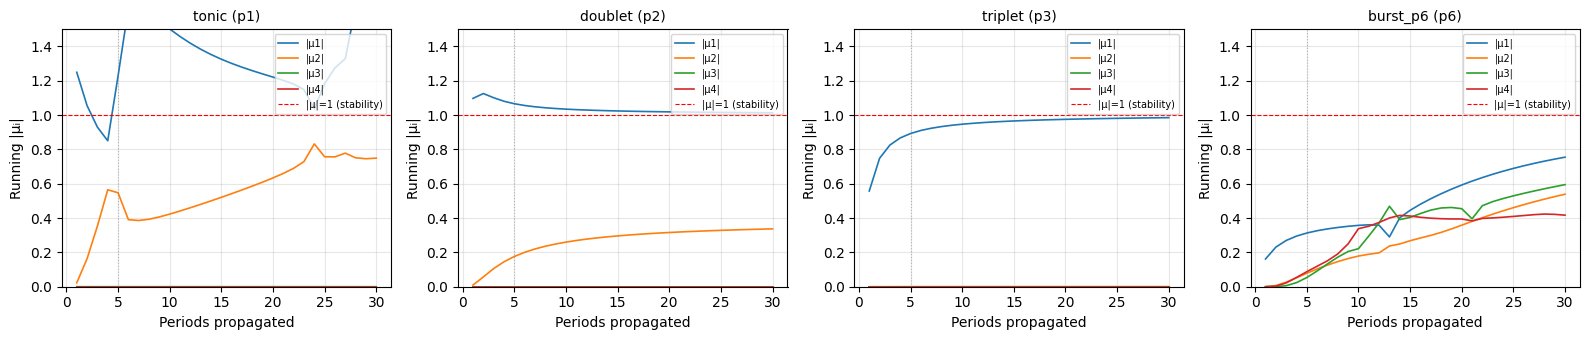

  Saved: /content/drive/My Drive/HHSMC/full_study/PS0b_floquet/PS0b_floquet_table.png


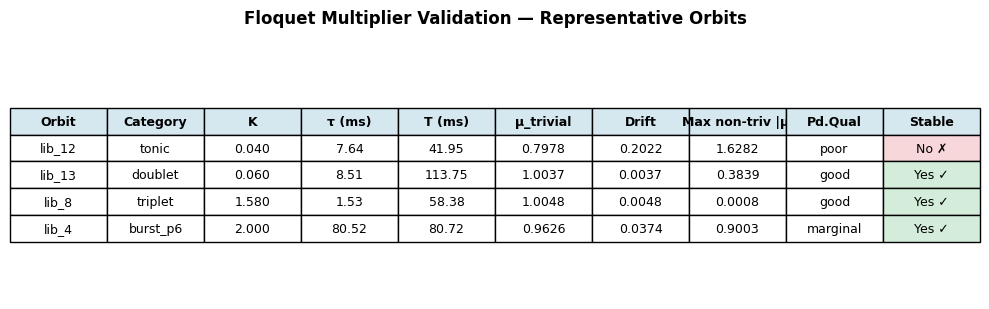


PS0b COMPLETE — ALL RESULTS SAVED
Output directory: /content/drive/My Drive/HHSMC/full_study/PS0b_floquet
Files:
  PS0b_floquet_results.json     — Summary results
  PS0b_floquet_full.json        — Full convergence history
  PS0b_floquet_convergence.png  — Convergence plots
  PS0b_floquet_table.png        — Results table


In [18]:
if __name__ == '__main__' or True:

    print("="*70)
    print("PS0b — FLOQUET MULTIPLIER VALIDATION")
    print("Option C: HH Delay-Directed Orbit Selection")
    print("="*70)

    I_BIAS = 10.0  # μA/cm²

    # ==== LOAD LIBRARY ====
    print("\n" + "="*50)
    print("Loading PS1 Library")
    print("="*50)
    library = load_library(PS1_DIR)

    # ==== SELECT REPRESENTATIVES ====
    print("\n" + "="*50)
    print("Selecting Representative Orbits")
    print("="*50)
    selected = select_representative_orbits(library)

    # ==== COMPUTE FLOQUET MULTIPLIERS ====
    print("\n" + "="*50)
    print("Computing Floquet Multipliers")
    print("="*50)

    all_results = []
    for orb in selected:
        print(f"\n  --- {orb['category']} (lib_idx={orb['lib_idx']}, "
              f"ISI={orb['isi_mean']:.2f} ms) ---")

        result = compute_floquet_multipliers(
            I_bias=I_BIAS,
            K=orb['representative_K'],
            tau_ms=orb['representative_tau'],
            pattern_length=orb['pattern_length'],
            T_settle_ms=5000.0,
            n_periods=30,
            dt=DT
        )

        if result is not None:
            # Attach orbit metadata
            result['lib_idx'] = orb['lib_idx']
            result['category'] = orb['category']
            result['pattern_length'] = orb['pattern_length']
            result['K'] = orb['representative_K']
            result['tau_ms'] = orb['representative_tau']
            result['isi_mean'] = orb['isi_mean']
            all_results.append(result)
        else:
            print(f"    FAILED for {orb['category']}")

    # ==== SUMMARY ====
    print("\n" + "="*70)
    print("FLOQUET VALIDATION SUMMARY")
    print("="*70)
    print(f"\n  {'Category':<14s} {'K':>6s} {'τ(ms)':>8s} {'T(ms)':>8s} "
          f"{'|μ₁|':>8s} {'|μ₂|':>8s} {'|μ₃|':>8s} {'|μ₄|':>8s} {'Stable':>8s}")
    print("  " + "-"*80)

    all_stable = True
    print(f"\n  {'Category':<14s} {'K':>6s} {'τ(ms)':>8s} {'T(ms)':>8s} "
          f"{'μ_triv':>8s} {'μ_max':>8s} {'PdQual':>8s} {'Stable':>8s}")
    print("  " + "-"*76)

    for r in all_results:
        stable_str = "✓ Yes" if r['stable'] else "✗ No"
        if not r['stable']:
            all_stable = False
        print(f"  {r['category']:<14s} {r['K']:6.3f} {r['tau_ms']:8.2f} "
              f"{r['T_period_ms']:8.2f} {r['trivial_mu']:8.4f} "
              f"{r['max_nontrivial_mu']:8.4f} {r['period_quality']:>8s} "
              f"{stable_str:>8s}")

    print("  " + "-"*76)
    print("\n  Note: μ_triv is the trivial Floquet multiplier (expected = 1.0).")
    print("  Stability is assessed from the max NON-TRIVIAL multiplier μ_max.")
    print("  PdQual = period quality (good: drift<2%, marginal: <10%, poor: ≥10%).")
    if all_stable:
        print("\n  ✓✓✓ ALL REPRESENTATIVE ORBITS CONFIRMED STABLE ✓✓✓")
        print("  All non-trivial |μᵢ| < 1. Floquet analysis validates the")
        print("  empirical stability convention (Section 2.1).")
    else:
        n_stable = sum(1 for r in all_results if r['stable'])
        n_total = len(all_results)
        print(f"\n  {n_stable}/{n_total} orbits confirmed stable.")
        for r in all_results:
            if not r['stable']:
                print(f"  ⚠ {r['category']}: max non-trivial |μ|={r['max_nontrivial_mu']:.4f}, "
                      f"period quality={r['period_quality']}")

    # ==== VISUALIZATION ====
    print("\n" + "="*50)
    print("Generating Figures")
    print("="*50)
    plot_convergence(all_results, save_dir=OUTPUT_DIR)
    plot_summary_table(all_results, save_dir=OUTPUT_DIR)

    # ==== SAVE ====
    # Strip heavy log_R_history for JSON (keep first/last 5 periods)
    results_light = []
    for r in all_results:
        rl = {k: v for k, v in r.items() if k != 'log_R_history'}
        log_R = r['log_R_history']
        rl['log_R_first5'] = log_R[:5]
        rl['log_R_last5'] = log_R[-5:]
        results_light.append(rl)

    with open(os.path.join(OUTPUT_DIR, 'PS0b_floquet_results.json'), 'w') as f:
        json.dump(results_light, f, indent=2)

    # Full results with convergence history
    with open(os.path.join(OUTPUT_DIR, 'PS0b_floquet_full.json'), 'w') as f:
        json.dump(all_results, f, indent=2)

    print(f"\n{'='*70}")
    print(f"PS0b COMPLETE — ALL RESULTS SAVED")
    print(f"{'='*70}")
    print(f"Output directory: {OUTPUT_DIR}")
    print(f"Files:")
    print(f"  PS0b_floquet_results.json     — Summary results")
    print(f"  PS0b_floquet_full.json        — Full convergence history")
    print(f"  PS0b_floquet_convergence.png  — Convergence plots")
    print(f"  PS0b_floquet_table.png        — Results table")